In [23]:
import h5py as h5 

import matplotlib.pyplot as plt
from matplotlib import cm, colors
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib import colors, ticker

import numpy as np
import pandas as pd
import os, sys, glob
import traceback
import re

from dotenv import load_dotenv
from datetime import datetime
# Load variables from .env
load_dotenv()

import h5flow 
plt.style.use('../../utils/dune.mplstyle')


# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(repo_root)

import time 
from collections import defaultdict


In [24]:
def extract_datetime(filename):
    # Get just the base name
    base = os.path.basename(filename)
    
    # Split and extract the timestamp part
    # packet-0060186-2025_12_13_02_21_47_CST.FLOW.csv
    parts = base.split('-')
    
    datetime_str = parts[2]  # "2025_12_13_02_21_47_CST.FLOW.csv"
    
    # Remove suffix
    datetime_str = datetime_str.replace("_CST.FLOW.csv", "")
    
    # Convert to datetime
    return datetime.strptime(datetime_str, "%Y_%m_%d_%H_%M_%S")

In [25]:

# Get files
files = glob.glob("/pscratch/sd/l/lmlepin/cluster_outputs/DTG_data_test_03-30_20260330_165040_clusters/*")

# Function to extract datetime
def extract_dt(path):
    fname = os.path.basename(path)
    m = re.search(r'packet-\d+-(\d{4}_\d{2}_\d{2}_\d{2}_\d{2}_\d{2})', fname)
    if not m:
        raise ValueError(f"Could not extract timestamp from {fname}")
    return datetime.strptime(m.group(1), "%Y_%m_%d_%H_%M_%S")

# Sort files by timestamp
files_sorted = sorted(files, key=extract_dt)

# Loop over them
DEBUG = 10

ifile = 0
for f in files_sorted:
    if(ifile > DEBUG):
        break
    df = pd.read_csv(f)
    print(f, df.shape)
    ifile+=1



/pscratch/sd/l/lmlepin/cluster_outputs/DTG_data_test_03-30_20260330_165040_clusters/packet-0060178-2025_12_12_15_59_36_CST.FLOW.hdf5.chunk_0107.csv (562386, 11)
/pscratch/sd/l/lmlepin/cluster_outputs/DTG_data_test_03-30_20260330_165040_clusters/packet-0060178-2025_12_12_15_59_36_CST.FLOW.hdf5.chunk_0011.csv (547219, 11)
/pscratch/sd/l/lmlepin/cluster_outputs/DTG_data_test_03-30_20260330_165040_clusters/packet-0060178-2025_12_12_15_59_36_CST.FLOW.hdf5.chunk_0029.csv (1116387, 11)
/pscratch/sd/l/lmlepin/cluster_outputs/DTG_data_test_03-30_20260330_165040_clusters/packet-0060178-2025_12_12_15_59_36_CST.FLOW.hdf5.chunk_0172.csv (1199674, 11)
/pscratch/sd/l/lmlepin/cluster_outputs/DTG_data_test_03-30_20260330_165040_clusters/packet-0060178-2025_12_12_15_59_36_CST.FLOW.hdf5.chunk_0097.csv (572680, 11)
/pscratch/sd/l/lmlepin/cluster_outputs/DTG_data_test_03-30_20260330_165040_clusters/packet-0060178-2025_12_12_15_59_36_CST.FLOW.hdf5.chunk_0121.csv (1136621, 11)
/pscratch/sd/l/lmlepin/cluster_

In [26]:
# Per-io containers
E_hits = defaultdict(list)
Q_hits = defaultdict(list)
E_cluster = defaultdict(list)
E_cluster_low = defaultdict(list)

# NEW: container for unique (file_id, event_id)
unique_pairs = set()

t_start = time.time()
file_index = 0

for f in files:
    if file_index > DEBUG:
        break

    df = pd.read_csv(f)

    # NEW: collect unique (file_id, event_id) pairs
    unique_pairs.update(zip(df['file_id'], df['light_id']))

    # Loop over each io group in the file
    for io_val, df_io in df.groupby('io'):

        # Collect hit-level info per io
        E_hits[io_val].extend(df_io['E'].values)
        Q_hits[io_val].extend(df_io['Q'].values)

        # Group by cluster id within this io
        grouped = df_io.groupby('id')

        # Cluster properties
        cluster_sizes = grouped.size()
        cluster_energy = grouped['E'].sum()

        # Cuts
        mask = (cluster_sizes >= 5) & (cluster_sizes < 15)
        mask_low = (cluster_sizes <= 2)

        # Store per io
        E_cluster[io_val].extend(cluster_energy[mask].values)
        E_cluster_low[io_val].extend(cluster_energy[mask_low].values)

    file_index += 1

print(f"Elapsed time {time.time() - t_start}")

# NEW: print result
print(f"Unique (file_id, event_id) pairs: {len(unique_pairs)}")

Elapsed time 13.807719945907593
Unique (file_id, event_id) pairs: 21985


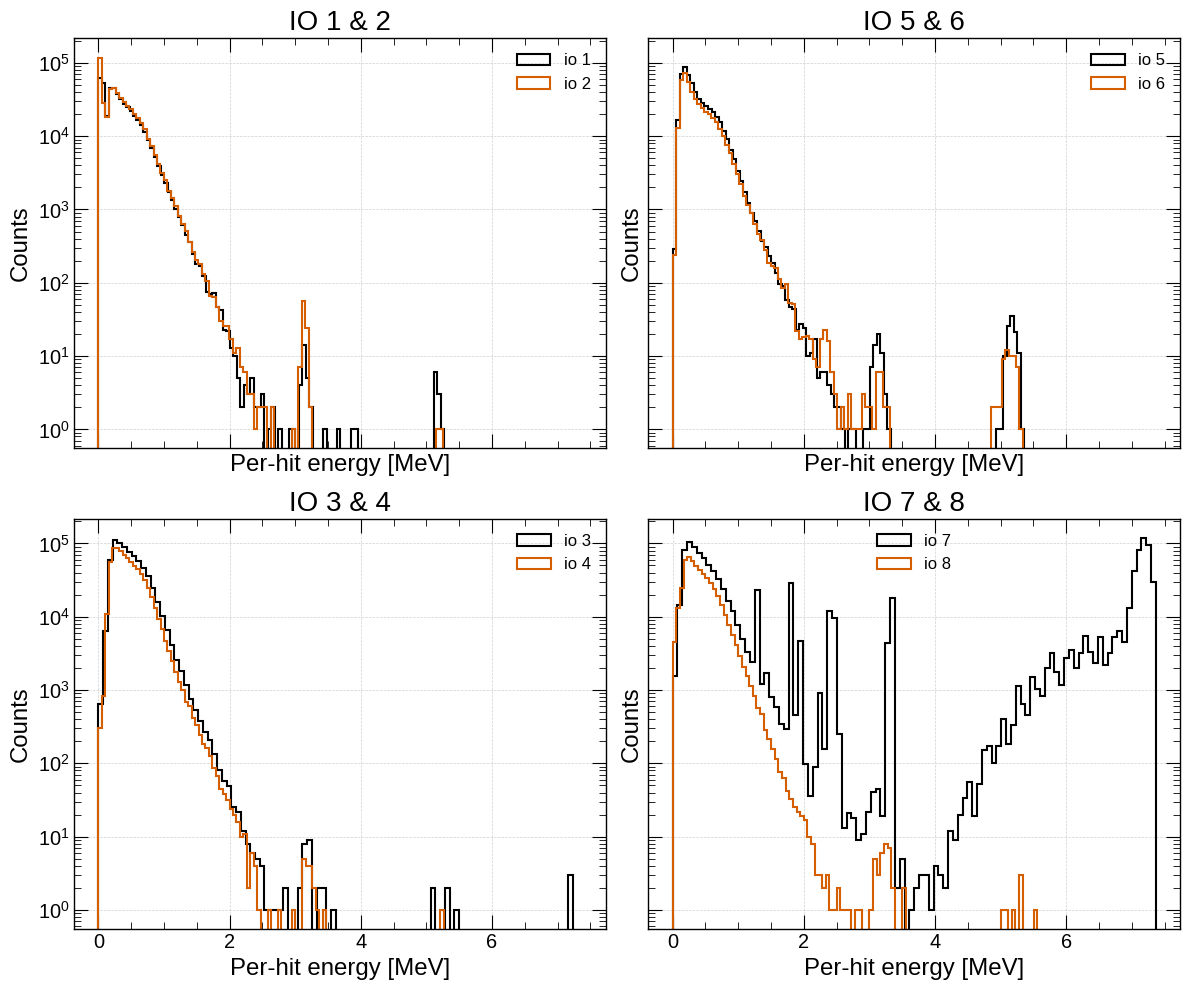

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

# Mapping panels → IO groups
panel_map = {
    (0, 0): [1, 2],   # top left
    (1, 0): [3, 4],   # bottom left
    (0, 1): [5, 6],   # top right
    (1, 1): [7, 8],   # bottom right
}

for (row, col), io_list in panel_map.items():
    ax = axes[row, col]

    for io_val in io_list:
        if io_val in E_hits:
            ax.hist(
                E_hits[io_val],
                bins=100,
                histtype='step',
                label=f'io {io_val}'
            )

    ax.set_title(f'IO {io_list[0]} & {io_list[1]}',fontsize=20)
    ax.set_yscale('log')
    ax.set_xlabel('Per-hit energy [MeV]')
    ax.set_ylabel('Counts')
    ax.legend()
    ax.grid(alpha=0.6)

plt.tight_layout()
#plt.savefig('E_cluster_low_4panel.png', dpi=200, bbox_inches='tight')
plt.show()

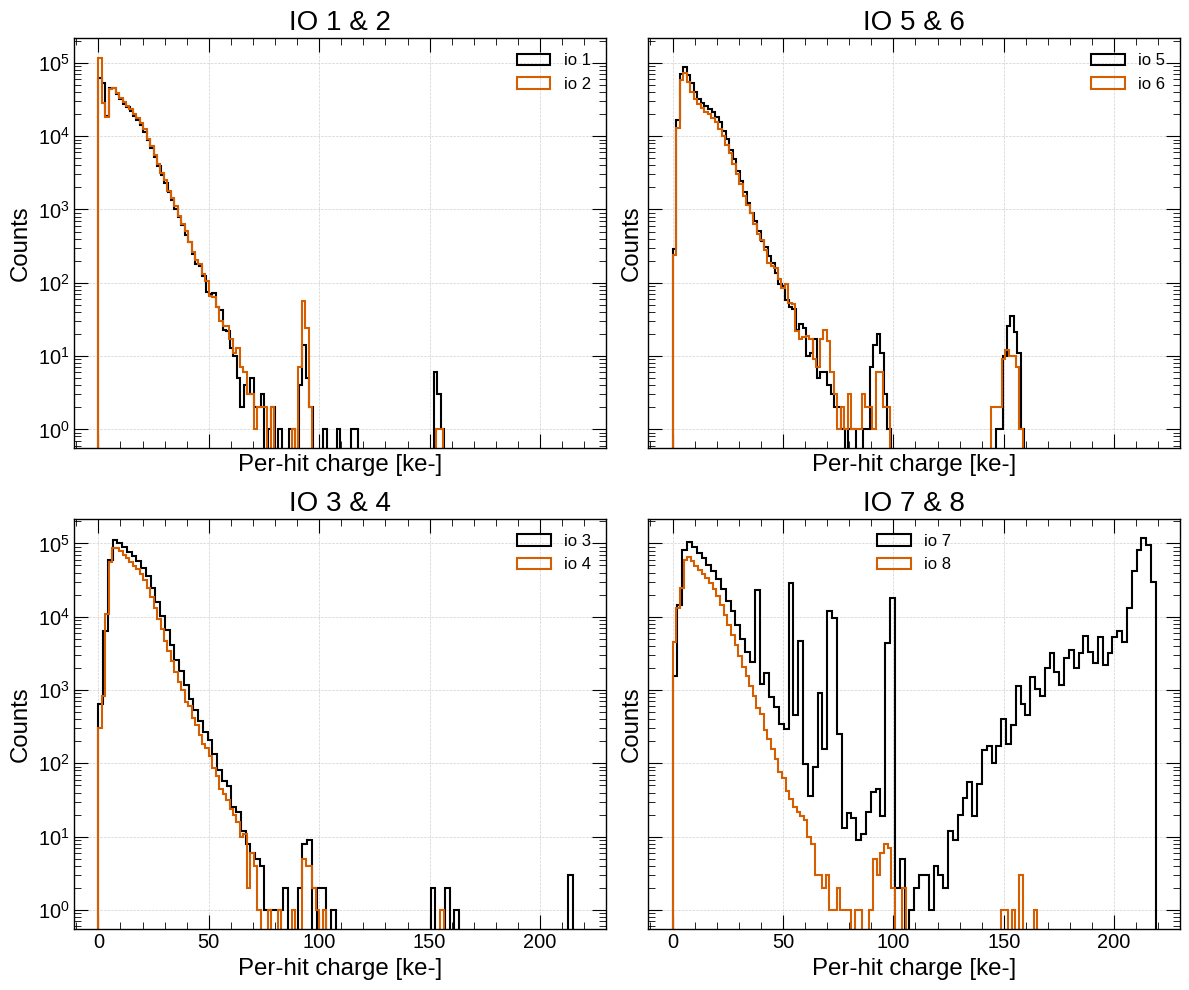

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

# Mapping panels → IO groups
panel_map = {
    (0, 0): [1, 2],   # top left
    (1, 0): [3, 4],   # bottom left
    (0, 1): [5, 6],   # top right
    (1, 1): [7, 8],   # bottom right
}

for (row, col), io_list in panel_map.items():
    ax = axes[row, col]

    for io_val in io_list:
        if io_val in Q_hits:
            ax.hist(
                Q_hits[io_val],
                bins=100,
                histtype='step',
                label=f'io {io_val}'
            )

    ax.set_title(f'IO {io_list[0]} & {io_list[1]}',fontsize=20)
    ax.set_yscale('log')
    ax.set_xlabel('Per-hit charge [ke-]')
    ax.set_ylabel('Counts')
    ax.legend()
    ax.grid(alpha=0.6)

plt.tight_layout()
#plt.savefig('E_cluster_low_4panel.png', dpi=200, bbox_inches='tight')
plt.show()

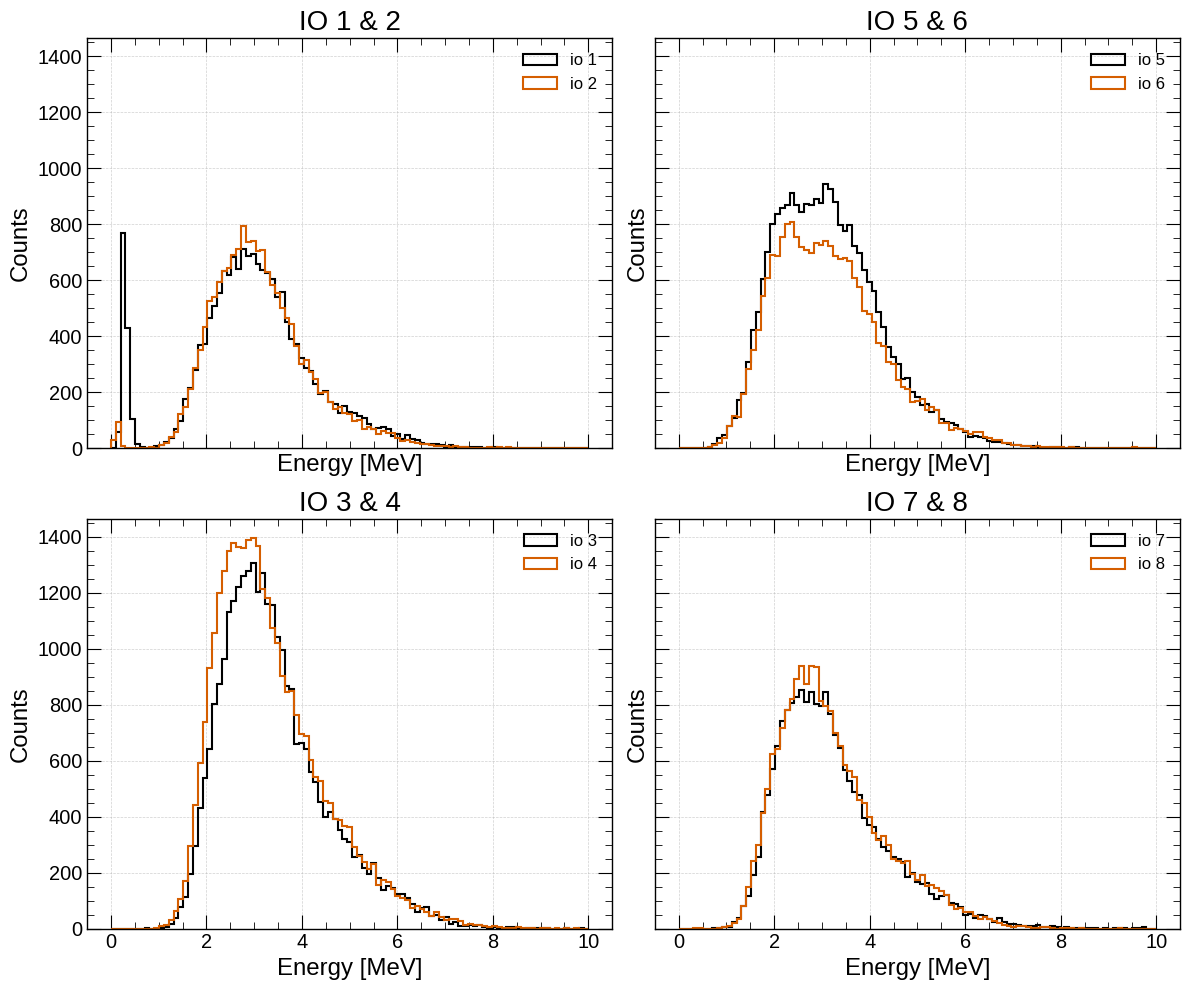

In [29]:
bins = np.linspace(0, 10., 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

# Mapping panels → IO groups
panel_map = {
    (0, 0): [1, 2],   # top left
    (1, 0): [3, 4],   # bottom left
    (0, 1): [5, 6],   # top right
    (1, 1): [7, 8],   # bottom right
}

for (row, col), io_list in panel_map.items():
    ax = axes[row, col]

    for io_val in io_list:
        if io_val in E_cluster:
            ax.hist(
                E_cluster[io_val],
                bins=bins,
                histtype='step',
                label=f'io {io_val}'
            )

    ax.set_title(f'IO {io_list[0]} & {io_list[1]}',fontsize=20)
    #ax.set_yscale('log')
    ax.set_xlabel('Energy [MeV]')
    ax.set_ylabel('Counts')
    ax.legend()
    ax.grid(alpha=0.6)

plt.tight_layout()
#plt.savefig('E_cluster_low_4panel.png', dpi=200, bbox_inches='tight')
plt.show()

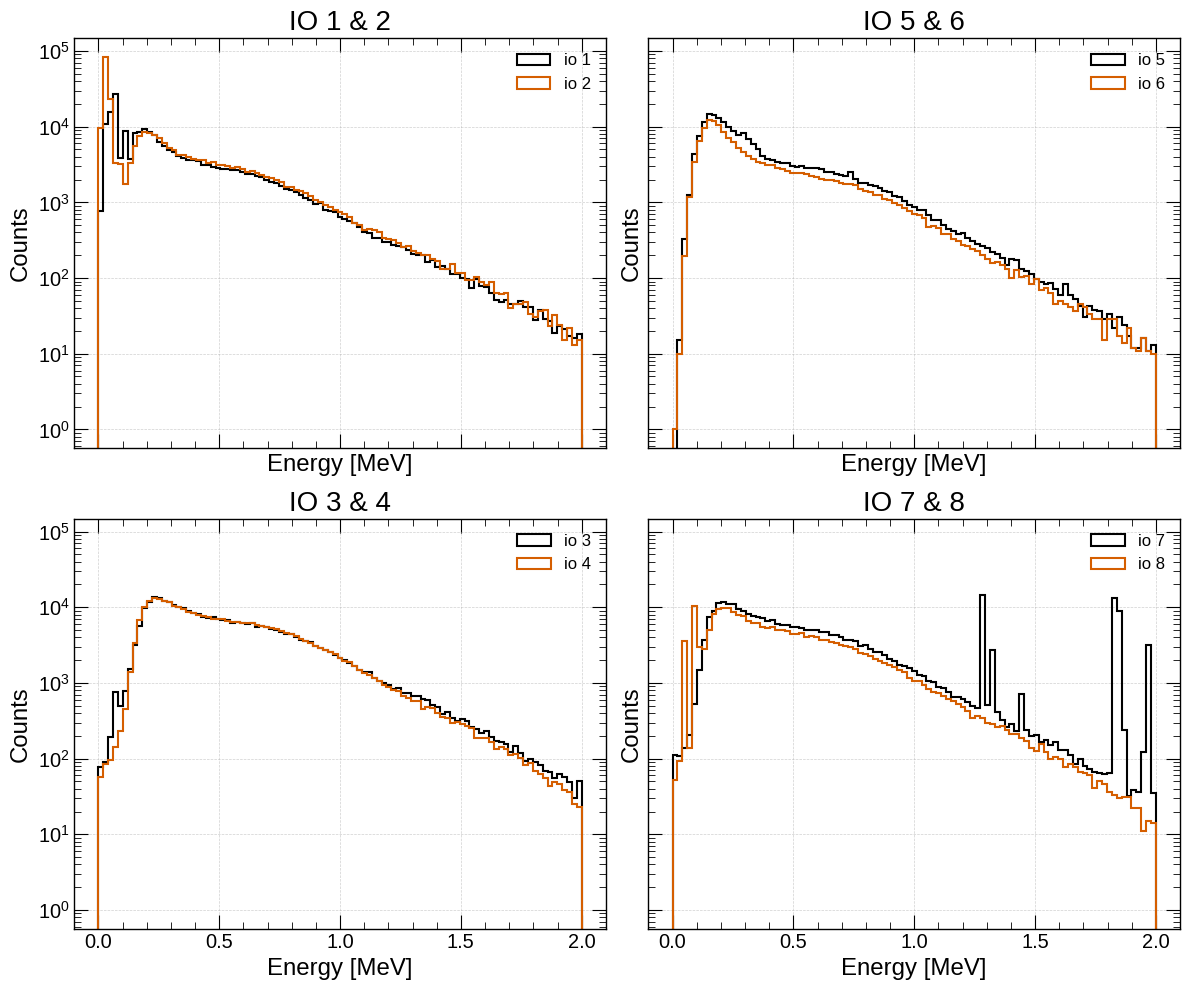

In [30]:
bins = np.linspace(0, 2, 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

# Mapping panels → IO groups
panel_map = {
    (0, 0): [1, 2],   # top left
    (1, 0): [3, 4],   # bottom left
    (0, 1): [5, 6],   # top right
    (1, 1): [7, 8],   # bottom right
}

for (row, col), io_list in panel_map.items():
    ax = axes[row, col]

    for io_val in io_list:
        if io_val in E_cluster_low:
            ax.hist(
                E_cluster_low[io_val],
                bins=bins,
                histtype='step',
                label=f'io {io_val}'
            )

    ax.set_title(f'IO {io_list[0]} & {io_list[1]}',fontsize=20)
    ax.set_yscale('log')
    ax.set_xlabel('Energy [MeV]')
    ax.set_ylabel('Counts')
    ax.legend()
    ax.grid(alpha=0.6)

plt.tight_layout()
#plt.savefig('E_cluster_low_4panel.png', dpi=200, bbox_inches='tight')
plt.show()